In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("linear_regression_dataset.csv")

# assume columns: x1..x12 and y
X_raw = df[[f"x{i}" for i in range(1, 13)]].values
y = df["y"].values.reshape(-1, 1)

n = X_raw.shape[0]
X = np.column_stack([np.ones((n, 1)), X_raw])  # add intercept

beta_hat = np.linalg.inv(X.T @ X) @ (X.T @ y)  # (p+1,1)

# sklearn comparison
lr = LinearRegression(fit_intercept=False)  # because we already added ones
lr.fit(X, y)

print("Closed-form beta:", beta_hat.ravel())
print("Sklearn beta:", lr.coef_.ravel())  # or lr.coef_ if y is 1D


Closed-form beta: [-0.07599727  3.01921283 -1.9986479   0.46532073  0.02874601  0.97888014
  0.00519653  0.05011683 -0.9177461   1.95197758 -0.01228502  0.05758946
  0.02741516]
Sklearn beta: [-0.07599727  3.01921283 -1.9986479   0.46532073  0.02874601  0.97888014
  0.00519653  0.05011683 -0.9177461   1.95197758 -0.01228502  0.05758946
  0.02741516]


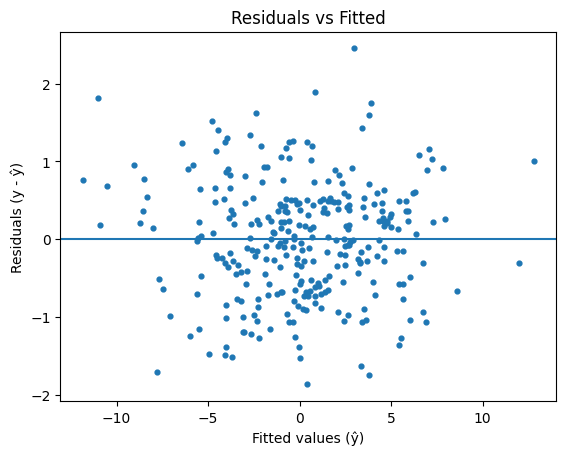

In [3]:
import matplotlib.pyplot as plt

y_hat = X @ beta_hat
resid = y - y_hat

plt.figure()
plt.scatter(y_hat, resid, s=12)
plt.axhline(0)
plt.xlabel("Fitted values (ŷ)")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residuals vs Fitted")
plt.show()


In [ ]:
# The residual cloud is centered around 0 with no strong curve → linearity looks fine

#Spread is fairly consistent across fitted values → variance roughly constant

#A few points show bigger residuals (possible mild outliers), but nothing extreme.

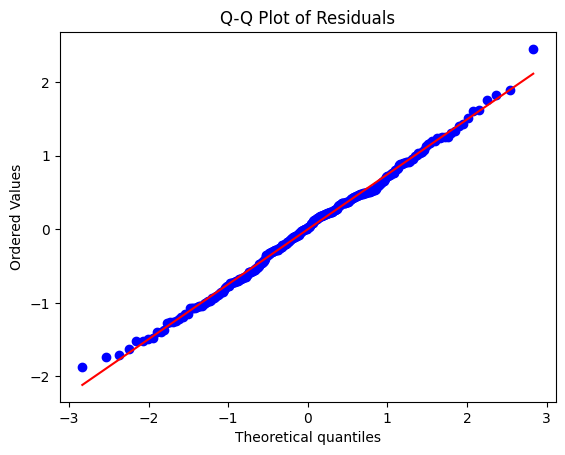

In [4]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure()
stats.probplot(resid.ravel(), dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()


In [ ]:
# answer 9
#Points mostly follow the diagonal line → residuals are approximately normal

#Some tail deviation is normal in real data; nothing too alarming here.

In [ ]:
# answer 10
# Based on your two plots:

# No major curvature → linearity assumption looks OK

# No funnel shape → homoscedasticity mostly OK

# Q–Q mostly straight → normality decent

# If these were violated, you would see:

# Curved residual pattern → missing nonlinear term

# Funnel → heteroscedasticity

# S-shaped Q–Q → heavy tails / skew / outliers

In [5]:
import numpy as np

XtX_inv = np.linalg.inv(X.T @ X)
H = X @ XtX_inv @ X.T
h = np.diag(H)

e = resid.ravel()
p1 = X.shape[1]  # p+1
mse = (e @ e) / (n - p1)

cook = (e**2 / (p1 * mse)) * (h / (1 - h)**2)

high_lev_idx = np.where(h > 2*p1/n)[0]
infl_idx = np.where(cook > 4/n)[0]

print("High leverage indices:", high_lev_idx)
print("Influential (Cook) indices:", infl_idx)


High leverage indices: [ 96 160 240]
Influential (Cook) indices: [ 18  59  86  88 116 117 121 129 146 155 267 286 293 296]


In [ ]:
# answer 11
# High leverage means unusual 
# 𝑥
# x-values; not necessarily harmful unless also large residual.

# Influential points can shift B strongly; removing them may change coefficients a lot.

In [6]:
import numpy as np

n = 300
x1 = np.random.randn(n)
z = np.random.randn(n)
x2 = x1 + 0.9*z
X = np.column_stack([np.ones(n), x1, x2])

XtX = X.T @ X
eigvals = np.linalg.eigvalsh(XtX)
cond = eigvals.max() / eigvals.min()
print("Condition number:", cond)


Condition number: 7.164654695331017


In [ ]:
# ANSWER 2